<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
display(df.head(5))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("Dimensiones:", df.ndim)

Dimensiones: 2


In [7]:
print("Columnas:", df.columns)

Columnas: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [8]:
print("Tipos de datos:\n", df.dtypes)

Tipos de datos:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [9]:
print("Nulos iniciales:\n", df.isnull().sum())

Nulos iniciales:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [11]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
df.drop(columns=["director"], inplace=True)

In [13]:
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

In [14]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [15]:
print("Nulos después de limpieza:\n", df.isnull().sum())

Nulos después de limpieza:
 show_id           0
type              0
title             0
cast            825
country           0
date_added        0
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64


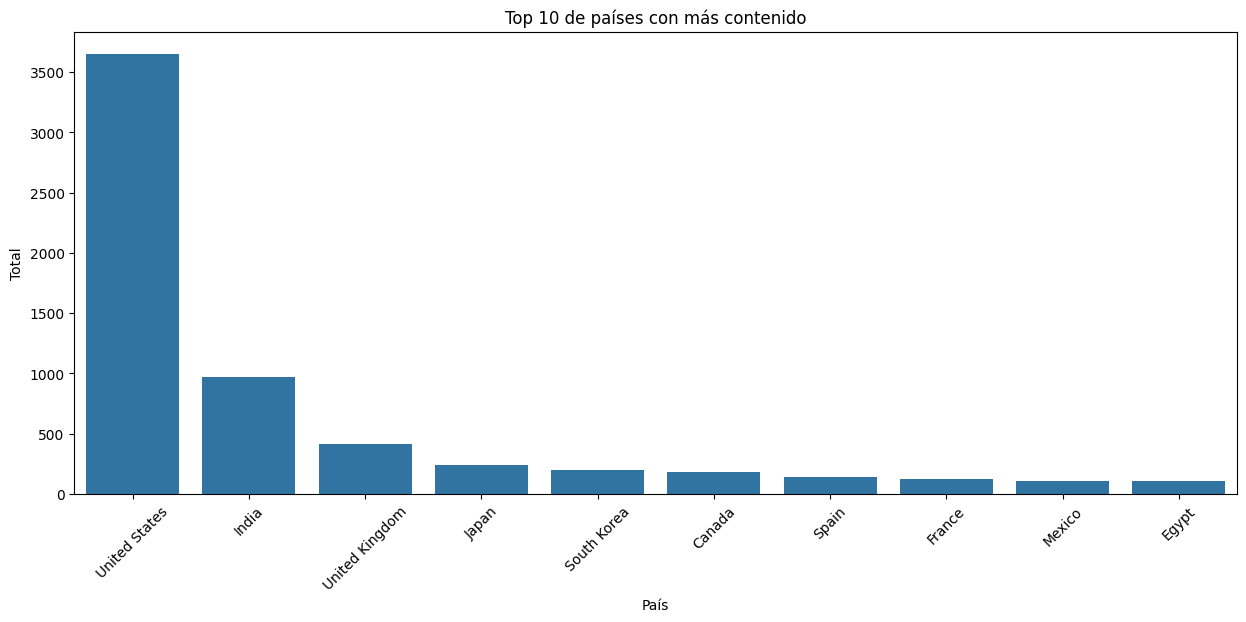

In [16]:
plt.figure(figsize=(15, 6))
top_paises = df['country'].value_counts().index[:10]
sns.countplot(data=df, x="country", order=top_paises)
plt.title("Top 10 de países con más contenido")
plt.xlabel("País")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.show()

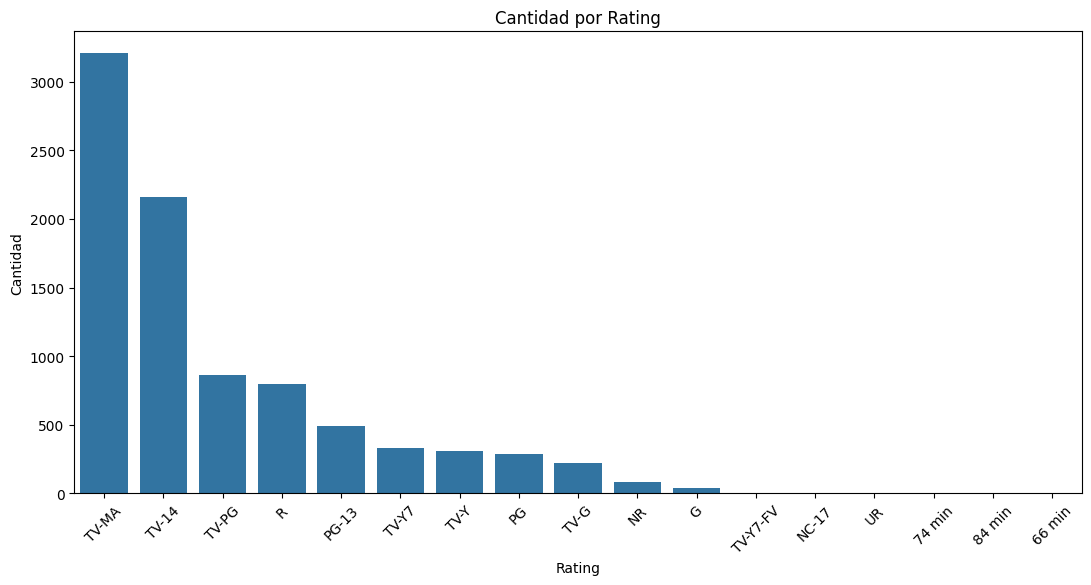

In [17]:
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x="rating", order=df['rating'].value_counts().index)
plt.title("Cantidad por Rating")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

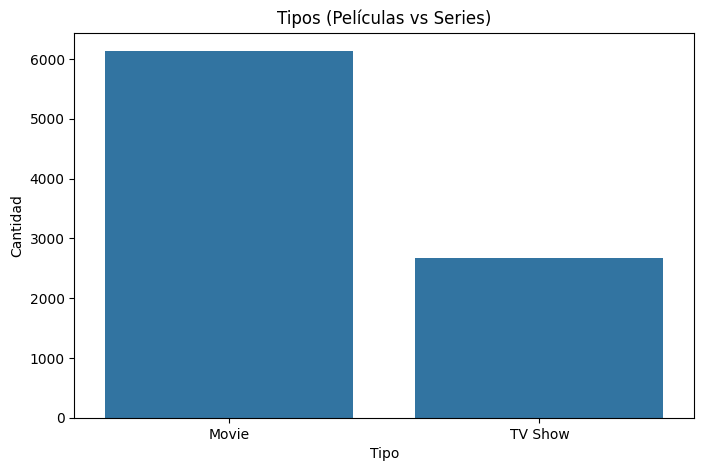

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type")
plt.title("Tipos (Películas vs Series)")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

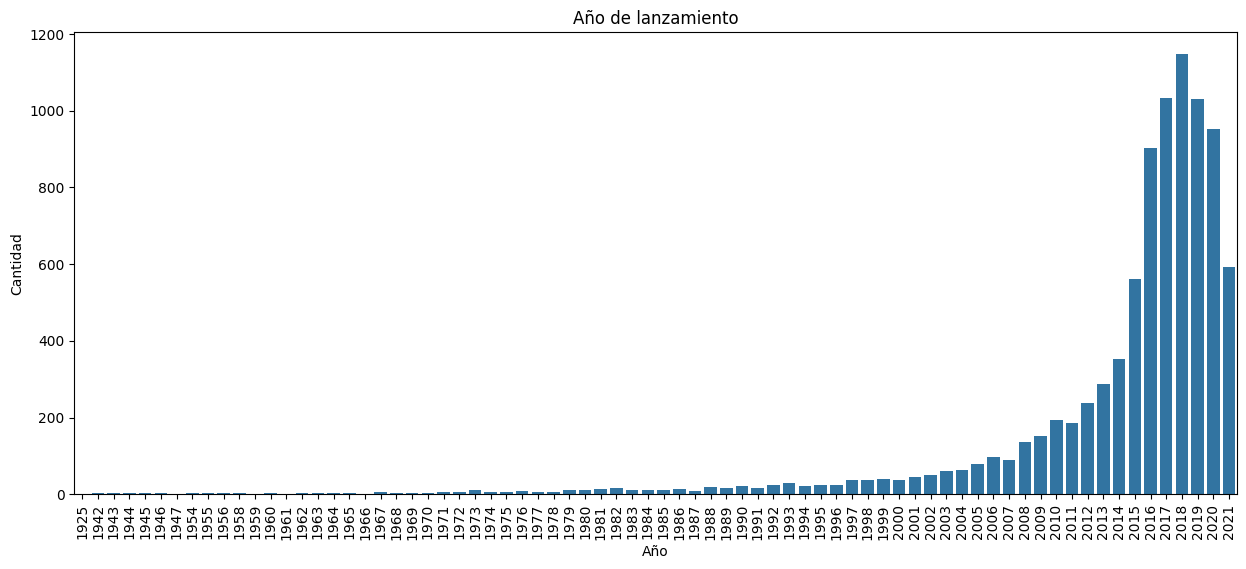

In [19]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x="release_year")
plt.title("Año de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.xticks(rotation=90)
plt.show()

# Interpretación de patrones (CAPA DE CONOCIMIENTOS)
# Escribe al menos 3 conclusiones derivadas del análisis.

# 1. Durante la fase de limpieza, se detectó que la variable 'director' presentaba una altísima tasa de valores nulos. Esto sugiere que para la plataforma no siempre es prioritario o posible registrar esta información, lo cual es muy común en formatos como las series de televisión.

# 2. Al observar la distribución histórica, es evidente un fuerte sesgo hacia el contenido moderno. Esto refleja una estrategia clara de la plataforma enfocada en la producción y adquisición de títulos recientes para mantener su catálogo actualizado, en lugar de priorizar obras clásicas.

# 3. La gráfica de clasificaciones (ratings) demuestra una concentración en categorías específicas (como TV-MA o TV-14). Esto nos permite concluir que el catálogo está diseñado estratégicamente para un público adulto y adolescente maduro, dejando en una menor proporción el contenido exclusivamente infantil.